In [1]:
import pandas as pd
import numpy as np
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, TimeDistributed, Lambda
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
path = '..../KDDTrain+.arff'
data, meta = arff.loadarff(path)
df = pd.DataFrame(data)
for col in df.select_dtypes([object]):
    df[col] = df[col].str.decode('utf-8')
df['label'] = (df[df.columns[-1]] != 'normal').astype(int)


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
})

missing_cols = missing_df[missing_df['Missing Count'] > 0]

if missing_cols.empty:
    print("No missing values found.")
else:
    print(f"Missing values found in {len(missing_cols)} column(s):\n")
    print(missing_cols.to_string())

print(f"Total rows       : {len(df)}")
print(f"Total columns    : {df.shape[1]}")
print(f"Total missing    : {df.isnull().sum().sum()}")
print(f"Affected columns : {len(missing_cols)}")

No missing values found.
Total rows       : 125973
Total columns    : 43
Total missing    : 0
Affected columns : 0


In [5]:
selected_features = [
    'num_access_files',
    'dst_bytes',
    'dst_host_count',
    'num_compromised',
    'dst_host_same_srv_rate',
    'same_srv_rate',
    'dst_host_srv_count',
    'serror_rate',
    'count',
    'rerror_rate',
    'dst_host_srv_rerror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_same_src_port_rate',
    'dst_host_serror_rate',
    'num_file_creations',
    'srv_count',
    'srv_serror_rate',
    'srv_rerror_rate',
    'srv_diff_host_rate',
    'wrong_fragment',
    'urgent',
    'src_bytes',
    'hot',
    'num_failed_logins'
]

print(f"Total features: {len(selected_features)}")

Total features: 25


In [6]:

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['protocol_type'] = label_encoder.fit_transform(df['protocol_type'])
df['flag'] = label_encoder.fit_transform(df['flag'])

In [7]:
X = df[selected_features].values
y = df.iloc[:, 42].values


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Reshape
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

# One-hot encoding label
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [10]:
# --- JaspenCorrelation Layer ---
class JaspenCorrelation(tf.keras.layers.Layer):
    def call(self, inputs):
        t, r = inputs  # t: (None, feat_dim), r: (None, REF_COUNT, feat_dim)
        t_exp = tf.expand_dims(t, 1)  # (None, 1, feat_dim)
        dot = tf.reduce_sum(t_exp * r, axis=2)  # (None, REF_COUNT)

        sum_t = tf.reduce_sum(t_exp, axis=2)  # (None, 1)
        sum_r = tf.reduce_sum(r, axis=2)      # (None, REF_COUNT)

        n = tf.cast(tf.shape(t)[1], tf.float32)
        corr = (n * dot - sum_t * sum_r) / (tf.sqrt(n * sum_t) * tf.sqrt(n * sum_r) + 1e-8)
        return tf.maximum(corr, 0.0)  # only positive correlation

def to_onehot_softmax(y):
    y = np.asarray(y)
    if y.ndim == 1:
        num_classes = int(np.max(y)) + 1
        y_oh = to_categorical(y, num_classes=num_classes)
    elif y.ndim == 2:
        row_sum = y.sum(axis=1, keepdims=True)
        row_sum[row_sum == 0] = 1.0
        y_oh = y / row_sum
    else:
        y_flat = y.reshape(len(y), -1)
        class_idx = np.argmax(y_flat, axis=1)
        num_classes = y_flat.shape[1]
        y_oh = to_categorical(class_idx, num_classes=num_classes)
    return y_oh

y_train = to_onehot_softmax(y_train)
y_test  = to_onehot_softmax(y_test)



In [11]:
SEQ_LEN = X_train.shape[1]
CHANNELS = 1
REF_COUNT = 20
NUM_CLASSES = y_train.shape[1]

# --- Inputs ---
test_input = Input(shape=(SEQ_LEN, CHANNELS), name="test_input")
reference_input = Input(shape=(REF_COUNT, SEQ_LEN, CHANNELS), name="reference_input")

# --- Shared CNN ---
shared_cnn = tf.keras.Sequential([
    Conv1D(64, 3, activation='relu'),
    MaxPooling1D(2),
    Conv1D(128, 3, activation='relu'),
    MaxPooling1D(2),
    Flatten()
], name='shared_cnn')

# Apply shared CNN
test_encoded = shared_cnn(test_input)  # (None, feat_dim)
reference_encoded = TimeDistributed(shared_cnn)(reference_input)  # (None, REF_COUNT, feat_dim)

# --- Correlation ---
corr = JaspenCorrelation()([test_encoded, reference_encoded])  # (None, REF_COUNT)
agg = Lambda(lambda x: tf.reduce_mean(x, axis=1, keepdims=True))(corr)  # (None, 1)

# --- Dense Output ---
x = Dense(128, activation='relu')(agg)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=[test_input, reference_input], outputs=output)

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ test_input          │ (None, 25, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reference_input     │ (None, 20, 25, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_cnn          │ (None, 512)       │     24,960 │ test_input[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 20, 512)   │     24,960 │ reference_input[… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ jaspen_correlation  │ (None, 20)        │          0 │ shared_cnn[0][0], │
│ (JaspenCorrelation) │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ jaspen_correlati… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │        256 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │        258 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,474 (99.51 KB)

 Trainable params: 25,474 (99.51 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
import time,tracemalloc
# Get 20 random references from the training set
reference_set = X_train[:REF_COUNT]
reference_input_train = np.repeat(reference_set[np.newaxis, :, :, :], X_train.shape[0], axis=0)
reference_input_test = np.repeat(reference_set[np.newaxis, :, :, :], X_test.shape[0], axis=0)
start = time.time()
tracemalloc.start()
# Train
history = model.fit(
    [X_train, reference_input_train],
    y_train,
    validation_data=([X_test, reference_input_test], y_test),
    epochs=10,
    batch_size=16
)
end = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

Epoch 1/10
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 89s 11ms/step - accuracy: 0.9482 - loss: 0.1488 - val_accuracy: 0.9590 - val_loss: 0.1005
Epoch 2/10
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 53s 8ms/step - accuracy: 0.9630 - loss: 0.0952 - val_accuracy: 0.9659 - val_loss: 0.0899
Epoch 3/10
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 54s 9ms/step - accuracy: 0.9663 - loss: 0.0845 - val_accuracy: 0.9656 - val_loss: 0.0862
Epoch 4/10
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 54s 9ms/step - accuracy: 0.9684 - loss: 0.0796 - val_accuracy: 0.9657 - val_loss: 0.0782
Epoch 5/10
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 52s 8ms/step - accuracy: 0.9697 - loss: 0.0762 - val_accuracy: 0.9677 - val_loss: 0.0715
Epoch 6/10
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 84s 9ms/step - accuracy: 0.9709 - loss: 0.0719 - val_accuracy: 0.9670 - val_loss: 0.0749
Epoch 7/10
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 53s 8ms/step - accuracy: 0.9722 - loss: 0.0696 - val_accuracy: 0.9737 - val_loss: 0.0646
Epoch 8/10
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 82s 8ms/step - accuracy: 0.9733 - loss: 

In [13]:
test_loss, test_accuracy = model.evaluate([X_test, reference_input_test], y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
print(f"\nTraining time: {end - start:.2f} seconds")
print(f"Memory usage: Current = {current / 10**6:.2f} MB; Peak = {peak / 10**6:.2f} MB")

788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9761 - loss: 0.0631
Test Loss: 0.0631, Test Accuracy: 0.9761

Training time: 657.97 seconds
Memory usage: Current = 10.14 MB; Peak = 425.54 MB


In [14]:
y_pred = model.predict([X_test, reference_input_test])
y_pred_binary = (y_pred > 0.5).astype(int)
y_true_binary = y_test.astype(int)


788/788 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step


In [15]:
cm = confusion_matrix(y_true_binary.flatten(), y_pred_binary.flatten())
TN, FP, FN, TP = cm.ravel()
specificity = TN / (TN + FP + 1e-8)

precision = precision_score(y_test, y_pred_binary, average='macro')
recall = recall_score(y_test, y_pred_binary, average='macro')
f1 = f1_score(y_test, y_pred_binary, average='macro')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Specificity: {specificity:.4f}")

Precision: 0.9763
Recall: 0.9758
F1-Score: 0.9760
Specificity: 0.9761


In [16]:
eval_start = time.time()
test_loss, test_accuracy = model.evaluate([X_test, reference_input_test], y_test)
eval_end = time.time()
pred_start = time.time()
y_pred = model.predict([X_test, reference_input_test])
pred_end = time.time()


print(f"Training time: {end - start:.2f} seconds")
print(f"Evaluation time: {eval_end - eval_start:.2f} seconds")
print(f"Prediction time: {pred_end - pred_start:.2f} seconds")
print(f"Total time: {(end - start) + (eval_end - eval_start) + (pred_end - pred_start):.2f} seconds")


788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9761 - loss: 0.0631
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Training time: 657.97 seconds
Evaluation time: 3.53 seconds
Prediction time: 3.77 seconds
Total time: 665.27 seconds


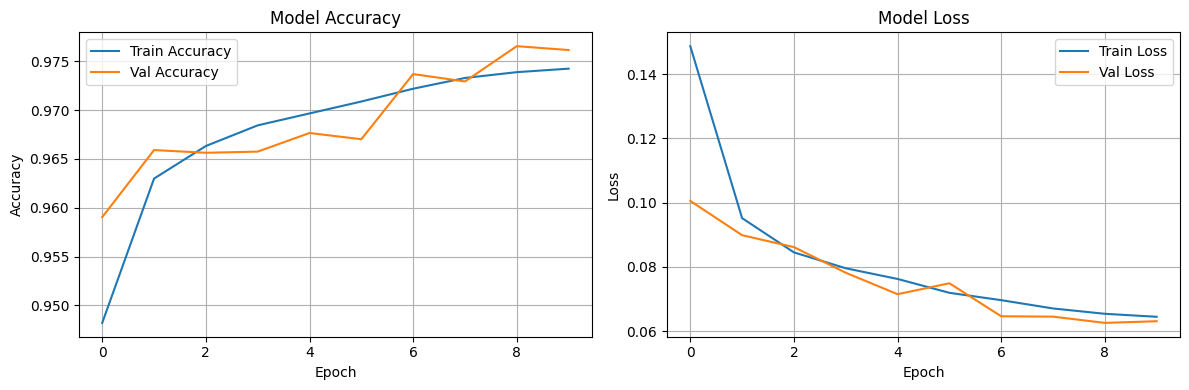

In [17]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()